In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
os.chdir(r"C:\Users\gotta\OneDrive\Documents\Bureau\X\4A\US\Stanford\Classes\CS 230\Project\CS-230-Deep-Learning-Project")

In [2]:
# 1. Data Preparation
def create_sliding_window(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data['LMP'].iloc[i:i + window_size].values)
        y.append(data['LMP'].iloc[i + window_size])
    return np.array(X), np.array(y)


In [3]:

# 2. Build the Model
def build_model(input_shape, layer_dims, l2_lambda=0.01):
    """
    Build a TensorFlow model with L2 regularization.

    Arguments:
    input_shape -- shape of the input data
    layer_dims -- list of layer dimensions
    l2_lambda -- L2 regularization parameter

    Returns:
    model -- compiled TensorFlow model
    """
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.InputLayer(input_shape=input_shape))
    for dim in layer_dims[:-1]:
        model.add(tf.keras.layers.Dense(dim, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(l2_lambda)))
    model.add(tf.keras.layers.Dense(layer_dims[-1], activation='linear', kernel_regularizer=tf.keras.regularizers.l2(l2_lambda)))
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse')
    return model


In [4]:

# 3. Train the Model
def train_model(model, X_train, y_train, X_dev, y_dev, batch_size, epochs):
    history = model.fit(
        X_train, y_train,
        validation_data=(X_dev, y_dev),
        batch_size=batch_size,
        epochs=epochs,
        verbose=1
    )
    return history


In [5]:

def evaluate_model(model, X, y):
    predictions = model.predict(X)
    mae_metric = tf.keras.metrics.MeanAbsoluteError()  # Create an instance of the metric
    mae_metric.update_state(y, predictions)  # Update the metric with true and predicted values
    mae = mae_metric.result().numpy()  # Get the result as a NumPy value
    return predictions, mae


In [6]:
def evaluate_model_with_rmae(model, X, y, t=24*7):
    """
    Evaluate the model and compute the relative Mean Absolute Error (rMAE) with a naive baseline.

    Arguments:
    model -- trained TensorFlow model
    X -- input data, shape (num_samples, window_size)
    y -- true labels, shape (num_samples, 1)
    t -- time lag for the naive baseline (default: 7 days = 24*7 hours)

    Returns:
    predictions -- model predictions
    rMAE -- relative Mean Absolute Error
    """
    # Model predictions
    predictions = model.predict(X)

    # Compute the naive baseline (price from the same hour 7 days earlier)
    if len(y) <= t:
        raise ValueError("Not enough data to compute the naive baseline (requires at least 7 days of data).")
    naive_baseline = np.roll(y, shift=-t, axis=0)  # Shift by 7 days
    naive_baseline[-t:] = y[-t:]  # Handle edge cases by copying the last valid values

    # Compute MAE for the model
    mae_model = np.mean(np.abs(predictions - y))

    # Compute MAE for the naive baseline
    mae_naive = np.mean(np.abs(naive_baseline - y))

    # Compute rMAE
    rmae = mae_model / mae_naive

    print(f"MAE (Model): {mae_model}")
    print(f"MAE (Naive Baseline): {mae_naive}")
    print(f"Relative MAE (rMAE): {rmae}")
    print(f"Accuracy (1 - rMAE): {1 - rmae}")

    return predictions, rmae

In [7]:

# Load data
df = pd.read_csv(r"data\CAISO_LMP_Forecasts\CAISO_LMP_Forecast_2022_07_to_2025_09.csv")
t = 168
X, y = create_sliding_window(df, t)
y = y.reshape(-1, 1)

# Normalize the data
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X = scaler_X.fit_transform(X)
y = scaler_y.fit_transform(y)

# Train/Dev split
train_end_index = int(len(X) * 0.8)
X_train, y_train = X[:train_end_index], y[:train_end_index]
X_dev, y_dev = X[train_end_index:], y[train_end_index:]
print(f"Training samples: {X_train.shape[0]}, Development samples: {X_dev.shape[0]}")


Training samples: 21926, Development samples: 5482


c:\Users\gotta\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Epoch 1/50
343/343 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 1.1858 - val_loss: 0.6525
Epoch 2/50
343/343 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5544 - val_loss: 0.3534
Epoch 3/50
343/343 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3369 - val_loss: 0.2243
Epoch 4/50
343/343 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2487 - val_loss: 0.1623
Epoch 5/50
343/343 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1998 - val_loss: 0.1300
Epoch 6/50
343/343 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1700 - val_loss: 0.1124
Epoch 7/50
343/343 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1540 - val_loss: 0.1004
Epoch 8/50
343/343 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1382 - val_loss: 0.0890
Epoch 9/50
343/343 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1378 - val_loss: 0.0836
Epoch 10/50
343/343 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1332 - val_loss: 0.0760
Epoch 11/50
343/343 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1223 - val_loss: 0.0766
Epoch 12/50
343/343 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

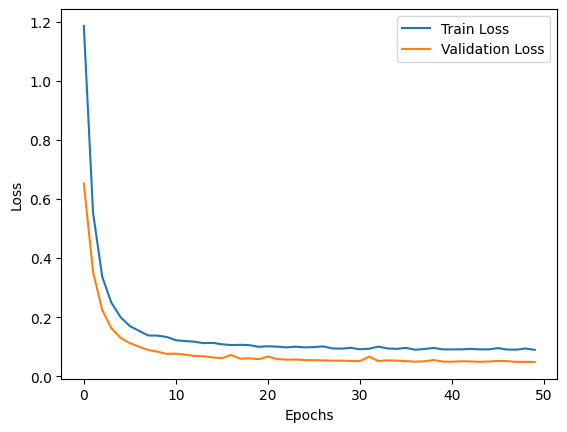

In [8]:

# Build and train the model
layer_dims = [64, 32, 16, 1]
model = build_model(input_shape=(t,), layer_dims=layer_dims, l2_lambda=0.01)
history = train_model(model, X_train, y_train, X_dev, y_dev, batch_size=64, epochs=50)

# Plot training history
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


686/686 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
MAE (Model): 0.11073057789203111
MAE (Naive Baseline): 0.3478592213929994
Relative MAE (rMAE): 0.3183200877889953
Accuracy (1 - rMAE): 0.6816799122110047
172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
MAE (Model): 0.04856166863917387
MAE (Naive Baseline): 0.15153975942252232
Relative MAE (rMAE): 0.32045496722595745
Accuracy (1 - rMAE): 0.6795450327740425
Train MAE: 0.3183200877889953, Dev MAE: 0.32045496722595745


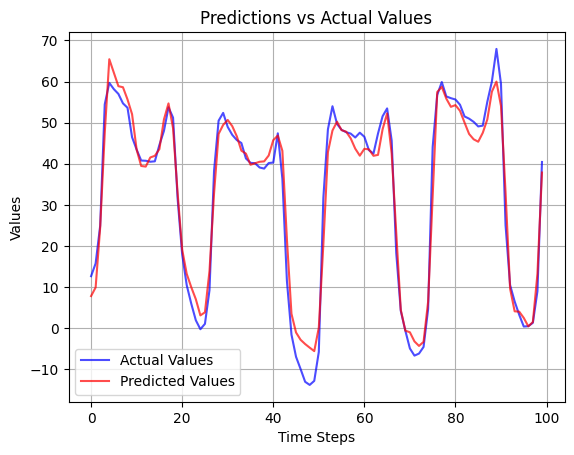

In [9]:

# Evaluate the model
predictions_train, mae_train = evaluate_model_with_rmae(model, X_train, y_train)
predictions_dev, mae_dev = evaluate_model_with_rmae(model, X_dev, y_dev)
print(f"Train MAE: {mae_train}, Dev MAE: {mae_dev}")

# Inverse transform predictions and actual values for plotting
predictions_dev_original = scaler_y.inverse_transform(predictions_dev)
y_dev_original = scaler_y.inverse_transform(y_dev)

 # Plot predictions vs actual values
plt.plot(y_dev_original.flatten()[:100], label="Actual Values", color="blue", alpha=0.7)
plt.plot(predictions_dev_original.flatten()[:100], label="Predicted Values", color="red", alpha=0.7)
plt.title("Predictions vs Actual Values")
plt.xlabel("Time Steps")
plt.ylabel("Values")
plt.legend()
plt.grid()
plt.show()

In [10]:
def hyperparameter_tuning(df, learning_rates, window_sizes, layer_dims, l2_lambda=0.01, batch_size=64, epochs=50):
    """
    Perform hyperparameter tuning for learning rate and window size.

    Arguments:
    df -- DataFrame containing the dataset
    learning_rates -- list of learning rates to try
    window_sizes -- list of window sizes to try
    layer_dims -- list of layer dimensions for the model
    l2_lambda -- L2 regularization parameter
    batch_size -- batch size for training
    epochs -- number of epochs for training

    Returns:
    results -- dictionary containing the results for each combination of hyperparameters
    best_params -- dictionary containing the best hyperparameters
    """
    results = []
    best_rmae = float('inf')
    best_params = None

    for lr in learning_rates:
        for t in window_sizes:
            print(f"Training with learning rate = {lr}, window size = {t}")

            # Create sliding window
            X, y = create_sliding_window(df, t)
            y = y.reshape(-1, 1)

            # Normalize the data
            scaler_X = StandardScaler()
            scaler_y = StandardScaler()
            X = scaler_X.fit_transform(X)
            y = scaler_y.fit_transform(y)

            # Train/Dev split
            train_end_index = int(len(X) * 0.8)
            X_train, y_train = X[:train_end_index], y[:train_end_index]
            X_dev, y_dev = X[train_end_index:], y[train_end_index:]

            # Build and train the model
            model = build_model(input_shape=(t,), layer_dims=layer_dims, l2_lambda=l2_lambda)
            model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr), loss='mse')
            history = train_model(model, X_train, y_train, X_dev, y_dev, batch_size=batch_size, epochs=epochs, verbose=0)

            # Evaluate the model
            _, rmae_dev = evaluate_model_with_rmae(model, X_dev, y_dev)

            # Store results
            results.append({
                'learning_rate': lr,
                'window_size': t,
                'rmae_dev': rmae_dev
            })

            # Update best parameters
            if rmae_dev < best_rmae:
                best_rmae = rmae_dev
                best_params = {'learning_rate': lr, 'window_size': t}

    return results, best_params

In [11]:
# Define search space
learning_rates = [0.001, 0.01, 0.1]
window_sizes = [50, 100, 200]
layer_dims = [64, 32, 16, 1]

# Perform hyperparameter tuning
results, best_params = hyperparameter_tuning(
    df=df,
    learning_rates=learning_rates,
    window_sizes=window_sizes,
    layer_dims=layer_dims,
    l2_lambda=0.01,
    batch_size=64,
    epochs=50
)

# Print results
print("Hyperparameter Tuning Results:")
for result in results:
    print(result)

print("\nBest Hyperparameters:")
print(best_params)

Training with learning rate = 0.001, window size = 50


c:\Users\gotta\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


TypeError: train_model() got an unexpected keyword argument 'verbose'

In [12]:
def hyperparameter_tuning_window_sizes(df, learning_rate, window_sizes, layer_dims, l2_lambda=0.01, batch_size=64, epochs=50):
    """
    Perform hyperparameter tuning for different window sizes with a fixed learning rate.

    Arguments:
    df -- DataFrame containing the dataset
    learning_rate -- fixed learning rate for Adam optimizer
    window_sizes -- list of window sizes to try
    layer_dims -- list of layer dimensions for the model
    l2_lambda -- L2 regularization parameter
    batch_size -- batch size for training
    epochs -- number of epochs for training

    Returns:
    results -- dictionary containing the results for each window size
    best_params -- dictionary containing the best window size
    """
    results = []
    best_rmae = float('inf')
    best_params = None

    for t in window_sizes:
        print(f"Training with window size = {t}")

        # Create sliding window
        X, y = create_sliding_window(df, t)
        y = y.reshape(-1, 1)

        # Normalize the data
        scaler_X = StandardScaler()
        scaler_y = StandardScaler()
        X = scaler_X.fit_transform(X)
        y = scaler_y.fit_transform(y)

        # Train/Dev split
        train_end_index = int(len(X) * 0.8)
        X_train, y_train = X[:train_end_index], y[:train_end_index]
        X_dev, y_dev = X[train_end_index:], y[train_end_index:]

        # Build and train the model
        model = build_model(input_shape=(t,), layer_dims=layer_dims, l2_lambda=l2_lambda)
        model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate), loss='mse')
        history = model.fit(
            X_train, y_train,
            validation_data=(X_dev, y_dev),
            batch_size=batch_size,
            epochs=epochs,
            verbose=0  # Suppress epoch-by-epoch printing
        )

        # Evaluate the model
        _, rmae_dev = evaluate_model_with_rmae(model, X_dev, y_dev)

        # Store results
        results.append({
            'window_size': t,
            'rmae_dev': rmae_dev
        })

        # Update best parameters
        if rmae_dev < best_rmae:
            best_rmae = rmae_dev
            best_params = {'window_size': t}

    return results, best_params
# Define search space
learning_rate = 0.001
window_sizes = [1, 10, 30, 168, 1000, 5000]
layer_dims = [64, 32, 16, 1]

# Perform hyperparameter tuning
results, best_params = hyperparameter_tuning_window_sizes(
    df=df,
    learning_rate=learning_rate,
    window_sizes=window_sizes,
    layer_dims=layer_dims,
    l2_lambda=0.01,
    batch_size=64,
    epochs=50
)

# Print results
print("Hyperparameter Tuning Results:")
for result in results:
    print(result)

print("\nBest Window Size:")
print(best_params)

Training with window size = 1


c:\Users\gotta\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
MAE (Model): 0.08521190419983879
MAE (Naive Baseline): 0.1524741467139222
Relative MAE (rMAE): 0.5588613285353654
Accuracy (1 - rMAE): 0.4411386714646346
Training with window size = 10


c:\Users\gotta\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
MAE (Model): 0.0783027979899925
MAE (Naive Baseline): 0.15245762781838287
Relative MAE (rMAE): 0.5136036753980701
Accuracy (1 - rMAE): 0.48639632460192994
Training with window size = 30


...

172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
MAE (Model): 0.06574389215933261
MAE (Naive Baseline): 0.15153975942252232
Relative MAE (rMAE): 0.4338392274731403
Accuracy (1 - rMAE): 0.5661607725268597
Training with window size = 1000


c:\Users\gotta\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
MAE (Model): 0.15440963301021057
MAE (Naive Baseline): 0.1509267876955615
Relative MAE (rMAE): 1.0230763893396737
Accuracy (1 - rMAE): -0.02307638933967371
Training with window size = 5000


c:\Users\gotta\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
MAE (Model): 0.1831598158670032
MAE (Naive Baseline): 0.2549821401511825
Relative MAE (rMAE): 0.718324098144306
Accuracy (1 - rMAE): 0.281675901855694
Hyperparameter Tuning Results:
{'window_size': 1, 'rmae_dev': np.float64(0.5588613285353654)}
{'window_size': 10, 'rmae_dev': np.float64(0.5136036753980701)}
{'window_size': 30, 'rmae_dev': np.float64(0.27503734846590394)}
{'window_size': 168, 'rmae_dev': np.float64(0.4338392274731403)}
{'window_size': 1000, 'rmae_dev': np.float64(1.0230763893396737)}
{'window_size': 5000, 'rmae_dev': np.float64(0.718324098144306)}

Best Window Size:
{'window_size': 30}
